#Importing Libraries


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
import warnings
warnings.filterwarnings('ignore')

#Importing the dataset


In [89]:
file_path = "//content/marketing_sample_for_easemytrip_in-easemytrip_flight_fares_data__20200101_20200229__30k_data.csv"
df = pd.read_csv(file_path)
df.head(10)

,Uniq Id,Crawl Timestamp,Source,Layover1,Layover2,Layover3,Destination,Flight Operator,Flight Number,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare
0,723b6dbcffbdfc2c29321c248cb14a9d,2020-02-01 00:46:15 +0000,Dubai,Muscat,Delhi,NaN,Kolkata,Oman Air|Oman Air|Air India,WY-612|WY-241|AI-764,06Feb2020,22:45,07Feb2020,19:10,18h 55m,2,26224.0
1,75624e36d7e8ea7e40cc5c33e6c96c01,2020-01-13 13:29:00 +0000,Delhi,NaN,NaN,NaN,Patna,SpiceJet,SG-8480,01Feb2020,15:45,01Feb2020,17:25,01h 40m,0,2889.0
2,0868155ae620dd8e7cd462e601b5f559,2020-01-01 00:35:50 +0000,Mumbai,Raipur,Kolkata,NaN,Silchar,Air India|Air India|Air India,AI-651|AI-9728|AI-753,23Jan2020,09:40,24Jan2020,07:00,21h 20m,2,13518.0
3,26135ec458c4204ddf036eae4119dd90,2020-02-01 00:33:23 +0000,Nagpur,Mumbai,Goa,NaN,Pune,Air India|Air India|Air India,AI-630|AI-33|AI-9562,03Feb2020,21:10,04Feb2020,14:45,17h 35m,2,12528.0
4,c29198e6745d72220af30969f05a7841,2020-01-01 00:18:01 +0000,Mumbai,Hyderabad,NaN,NaN,Varanasi,Indigo|Indigo,6E-5384|6E-915,06Jan2020,00:50,06Jan2020,10:05,09h 15m,1,8240.0
5,6fa9d449da680ba94ad777c77295f530,2020-02-01 00:51:40 +0000,Jeddah,Muscat,NaN,NaN,Hyderabad,Oman Air|Oman Air,WY-690|WY-231,17Feb2020,14:40,18Feb2020,13:50,20h 40m,1,14025.0
6,d254a0f82dcbd103bce0b0fcb6300b93,2020-01-01 00:21:59 +0000,Kochi,Delhi,NaN,NaN,Hyderabad,Vistara|Vistara,UK-884|UK-879,02Jan2020,09:30,02Jan2020,19:55,10h 25m,1,22333.0
7,db5a5740dc83fdd4457dbfb92f6d1f4a,2020-01-13 13:31:07 +0000,Bhopal,Jaipur,Mumbai,NaN,Hyderabad,Air India|Air India|Air India,AI-9684|AI-612|AI-619,01Feb2020,19:15,02Feb2020,20:45,25h 30m,2,9917.0
8,14bedfcf13184f2518d8e372aa17ca20,2020-02-01 00:50:56 +0000,Don Mueang,Kolkata,NaN,NaN,Mumbai,Hahn Air Systems|Hahn Air Systems,H1-9029|H1-1687,20Feb2020,05:10,20Feb2020,14:55,11h 15m,1,39274.0
9,c9423b9a6fc3ed7bde7f9df9ddebb2c8,2020-02-01 00:46:23 +0000,Riyadh,Sabiha Gokcen,NaN,NaN,Delhi,Turkish Airlines|Turkish Airlines,TK-147|TK-716,27Feb2020,04:00,28Feb2020,05:15,22h 45m,1,35344.0


#Data Analysis, Pre-Processing and Feature Extraction


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Uniq Id          30024 non-null  object 
 1   Crawl Timestamp  30024 non-null  object 
 2   Source           30024 non-null  object 
 3   Layover1         28720 non-null  object 
 4   Layover2         11242 non-null  object 
 5   Layover3         7 non-null      object 
 6   Destination      30024 non-null  object 
 7   Flight Operator  30024 non-null  object 
 8   Flight Number    30024 non-null  object 
 9   Departure Date   30024 non-null  object 
 10  Departure Time   30024 non-null  object 
 11  Arrival Date     30024 non-null  object 
 12  Arrival Time     30024 non-null  object 
 13  Total Time       30024 non-null  object 
 14  Number Of Stops  30024 non-null  int64  
 15  Fare             30024 non-null  float64
dtypes: float64(1), int64(1), object(14)
memory usage: 3.7+ MB


In [91]:
df.describe()

,Number Of Stops,Fare
count,30024.000000,30024.000000
mean,1.332367,34223.542699
std,0.554113,48169.945151
min,0.000000,1299.000000
25%,1.000000,9573.750000
50%,1.000000,16289.000000
75%,2.000000,41573.250000
max,3.000000,930341.000000


In [92]:
df.isnull().sum()

,0
Uniq Id,0
Crawl Timestamp,0
Source,0
Layover1,1304
Layover2,18782
Layover3,30017
Destination,0
Flight Operator,0
Flight Number,0
Departure Date,0


In [93]:
df["Layover3"].unique()

array([nan, 'Coimbatore', 'Ahmedabad', 'Raipur', 'Kolkata'], dtype=object)

In [94]:
df = df.drop(["Uniq Id", "Layover3", "Flight Number", "Crawl Timestamp"], axis = 1)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Source           30024 non-null  object 
 1   Layover1         28720 non-null  object 
 2   Layover2         11242 non-null  object 
 3   Destination      30024 non-null  object 
 4   Flight Operator  30024 non-null  object 
 5   Departure Date   30024 non-null  object 
 6   Departure Time   30024 non-null  object 
 7   Arrival Date     30024 non-null  object 
 8   Arrival Time     30024 non-null  object 
 9   Total Time       30024 non-null  object 
 10  Number Of Stops  30024 non-null  int64  
 11  Fare             30024 non-null  float64
dtypes: float64(1), int64(1), object(10)
memory usage: 2.7+ MB


In [96]:
df.head(10)

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,06Feb2020,22:45,07Feb2020,19:10,18h 55m,2,26224.0
1,Delhi,NaN,NaN,Patna,SpiceJet,01Feb2020,15:45,01Feb2020,17:25,01h 40m,0,2889.0
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,23Jan2020,09:40,24Jan2020,07:00,21h 20m,2,13518.0
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,03Feb2020,21:10,04Feb2020,14:45,17h 35m,2,12528.0
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,06Jan2020,00:50,06Jan2020,10:05,09h 15m,1,8240.0
5,Jeddah,Muscat,NaN,Hyderabad,Oman Air|Oman Air,17Feb2020,14:40,18Feb2020,13:50,20h 40m,1,14025.0
6,Kochi,Delhi,NaN,Hyderabad,Vistara|Vistara,02Jan2020,09:30,02Jan2020,19:55,10h 25m,1,22333.0
7,Bhopal,Jaipur,Mumbai,Hyderabad,Air India|Air India|Air India,01Feb2020,19:15,02Feb2020,20:45,25h 30m,2,9917.0
8,Don Mueang,Kolkata,NaN,Mumbai,Hahn Air Systems|Hahn Air Systems,20Feb2020,05:10,20Feb2020,14:55,11h 15m,1,39274.0
9,Riyadh,Sabiha Gokcen,NaN,Delhi,Turkish Airlines|Turkish Airlines,27Feb2020,04:00,28Feb2020,05:15,22h 45m,1,35344.0


#Extracting the First Flight of the Passenger

In [97]:
df["F_list"] = df["Flight Operator"].str.split('|')
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,06Feb2020,22:45,07Feb2020,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]"
1,Delhi,NaN,NaN,Patna,SpiceJet,01Feb2020,15:45,01Feb2020,17:25,01h 40m,0,2889.0,[SpiceJet]
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,23Jan2020,09:40,24Jan2020,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]"
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,03Feb2020,21:10,04Feb2020,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]"
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,06Jan2020,00:50,06Jan2020,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]"


In [98]:
df["Airline"] = [x[1][0] for x in enumerate(df["F_list"])]
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,06Feb2020,22:45,07Feb2020,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air
1,Delhi,NaN,NaN,Patna,SpiceJet,01Feb2020,15:45,01Feb2020,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,23Jan2020,09:40,24Jan2020,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,03Feb2020,21:10,04Feb2020,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,06Jan2020,00:50,06Jan2020,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo


#Extracting the Date-Time of the user Departure and Arrival in DateTime Format

In [99]:
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Jan", "01"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Feb", "02"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Mar", "03"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Apr", "04"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("May", "05"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Jun", "06"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Jul", "07"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Aug", "08"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Sep", "09"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Oct", "10"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Nov", "11"))
df["Departure Date"] = df["Departure Date"].apply(lambda x: x.replace("Dec", "12"))
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,06022020,22:45,07Feb2020,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air
1,Delhi,NaN,NaN,Patna,SpiceJet,01022020,15:45,01Feb2020,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,23012020,09:40,24Jan2020,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,03022020,21:10,04Feb2020,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,06012020,00:50,06Jan2020,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo


In [100]:
df['Departure Date'] = pd.to_datetime(df['Departure Date'], format='%d%m%Y')
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,07Feb2020,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,01Feb2020,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,24Jan2020,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,04Feb2020,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,06Jan2020,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo


In [101]:
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Jan", "01"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Feb", "02"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Mar", "03"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Apr", "04"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("May", "05"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Jun", "06"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Jul", "07"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Aug", "08"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Sep", "09"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Oct", "10"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Nov", "11"))
df["Arrival Date"] = df["Arrival Date"].apply(lambda x: x.replace("Dec", "12"))
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,07022020,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,01022020,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,24012020,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,04022020,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,06012020,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo


In [102]:
df['Arrival Date'] = pd.to_datetime(df['Arrival Date'], format='%d%m%Y')
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,2020-02-07,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,2020-02-01,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,2020-01-24,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,2020-02-04,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,2020-01-06,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Source           30024 non-null  object        
 1   Layover1         28720 non-null  object        
 2   Layover2         11242 non-null  object        
 3   Destination      30024 non-null  object        
 4   Flight Operator  30024 non-null  object        
 5   Departure Date   30024 non-null  datetime64[ns]
 6   Departure Time   30024 non-null  object        
 7   Arrival Date     30024 non-null  datetime64[ns]
 8   Arrival Time     30024 non-null  object        
 9   Total Time       30024 non-null  object        
 10  Number Of Stops  30024 non-null  int64         
 11  Fare             30024 non-null  float64       
 12  F_list           30024 non-null  object        
 13  Airline          30024 non-null  object        
dtypes: datetime64[ns](2), float64(1), int6

In [104]:
df['D_Time'] = pd.to_datetime(df['Departure Time'])
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline,D_Time
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,2020-02-07,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air,2026-01-08 22:45:00
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,2020-02-01,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet,2026-01-08 15:45:00
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,2020-01-24,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India,2026-01-08 09:40:00
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,2020-02-04,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India,2026-01-08 21:10:00
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,2020-01-06,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo,2026-01-08 00:50:00


In [105]:
df["D_Time"] = df["D_Time"].dt.time


In [106]:
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline,D_Time
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,2020-02-07,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air,22:45:00
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,2020-02-01,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet,15:45:00
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,2020-01-24,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India,09:40:00
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,2020-02-04,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India,21:10:00
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,2020-01-06,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo,00:50:00


In [107]:
df['A_Time'] = pd.to_datetime(df['Arrival Time'])

In [108]:
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline,D_Time,A_Time
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,2020-02-07,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air,22:45:00,2026-01-08 19:10:00
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,2020-02-01,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet,15:45:00,2026-01-08 17:25:00
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,2020-01-24,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India,09:40:00,2026-01-08 07:00:00
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,2020-02-04,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India,21:10:00,2026-01-08 14:45:00
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,2020-01-06,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo,00:50:00,2026-01-08 10:05:00


In [109]:
df["A_Time"] = df["A_Time"].dt.time

In [110]:
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline,D_Time,A_Time
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,2020-02-07,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air,22:45:00,19:10:00
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,2020-02-01,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet,15:45:00,17:25:00
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,2020-01-24,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India,09:40:00,07:00:00
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,2020-02-04,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India,21:10:00,14:45:00
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,2020-01-06,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo,00:50:00,10:05:00


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Source           30024 non-null  object        
 1   Layover1         28720 non-null  object        
 2   Layover2         11242 non-null  object        
 3   Destination      30024 non-null  object        
 4   Flight Operator  30024 non-null  object        
 5   Departure Date   30024 non-null  datetime64[ns]
 6   Departure Time   30024 non-null  object        
 7   Arrival Date     30024 non-null  datetime64[ns]
 8   Arrival Time     30024 non-null  object        
 9   Total Time       30024 non-null  object        
 10  Number Of Stops  30024 non-null  int64         
 11  Fare             30024 non-null  float64       
 12  F_list           30024 non-null  object        
 13  Airline          30024 non-null  object        
 14  D_Time           30024 non-null  objec

In [112]:
# Combining extracted date and time and get final results in required Format

import datetime
df['D_Date_Time'] = [datetime.datetime.combine(a, b) for a, b in zip(df['Departure Date'], df['D_Time'])]
df['A_Date_Time'] = [datetime.datetime.combine(a, b) for a, b in zip(df['Arrival Date'], df['A_Time'])]

In [113]:
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,Number Of Stops,Fare,F_list,Airline,D_Time,A_Time,D_Date_Time,A_Date_Time
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,2020-02-07,19:10,18h 55m,2,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air,22:45:00,19:10:00,2020-02-06 22:45:00,2020-02-07 19:10:00
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,2020-02-01,17:25,01h 40m,0,2889.0,[SpiceJet],SpiceJet,15:45:00,17:25:00,2020-02-01 15:45:00,2020-02-01 17:25:00
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,2020-01-24,07:00,21h 20m,2,13518.0,"[Air India, Air India, Air India]",Air India,09:40:00,07:00:00,2020-01-23 09:40:00,2020-01-24 07:00:00
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,2020-02-04,14:45,17h 35m,2,12528.0,"[Air India, Air India, Air India]",Air India,21:10:00,14:45:00,2020-02-03 21:10:00,2020-02-04 14:45:00
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,2020-01-06,10:05,09h 15m,1,8240.0,"[Indigo, Indigo]",Indigo,00:50:00,10:05:00,2020-01-06 00:50:00,2020-01-06 10:05:00


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Source           30024 non-null  object        
 1   Layover1         28720 non-null  object        
 2   Layover2         11242 non-null  object        
 3   Destination      30024 non-null  object        
 4   Flight Operator  30024 non-null  object        
 5   Departure Date   30024 non-null  datetime64[ns]
 6   Departure Time   30024 non-null  object        
 7   Arrival Date     30024 non-null  datetime64[ns]
 8   Arrival Time     30024 non-null  object        
 9   Total Time       30024 non-null  object        
 10  Number Of Stops  30024 non-null  int64         
 11  Fare             30024 non-null  float64       
 12  F_list           30024 non-null  object        
 13  Airline          30024 non-null  object        
 14  D_Time           30024 non-null  objec

#Feature Engineering: Using the extracted data to get a usefull feature

In [117]:
df["Day"] = df["D_Date_Time"].dt.day
df["Month"] = df["D_Date_Time"].dt.month
df['Total Hrs'] = round((df['A_Date_Time'] - df['D_Date_Time']).dt.total_seconds() / 60 / 60, 2)

In [118]:
df.head()

,Source,Layover1,Layover2,Destination,Flight Operator,Departure Date,Departure Time,Arrival Date,Arrival Time,Total Time,...,Fare,F_list,Airline,D_Time,A_Time,D_Date_Time,A_Date_Time,Day,Month,Total Hrs
0,Dubai,Muscat,Delhi,Kolkata,Oman Air|Oman Air|Air India,2020-02-06,22:45,2020-02-07,19:10,18h 55m,...,26224.0,"[Oman Air, Oman Air, Air India]",Oman Air,22:45:00,19:10:00,2020-02-06 22:45:00,2020-02-07 19:10:00,6,2,20.42
1,Delhi,NaN,NaN,Patna,SpiceJet,2020-02-01,15:45,2020-02-01,17:25,01h 40m,...,2889.0,[SpiceJet],SpiceJet,15:45:00,17:25:00,2020-02-01 15:45:00,2020-02-01 17:25:00,1,2,1.67
2,Mumbai,Raipur,Kolkata,Silchar,Air India|Air India|Air India,2020-01-23,09:40,2020-01-24,07:00,21h 20m,...,13518.0,"[Air India, Air India, Air India]",Air India,09:40:00,07:00:00,2020-01-23 09:40:00,2020-01-24 07:00:00,23,1,21.33
3,Nagpur,Mumbai,Goa,Pune,Air India|Air India|Air India,2020-02-03,21:10,2020-02-04,14:45,17h 35m,...,12528.0,"[Air India, Air India, Air India]",Air India,21:10:00,14:45:00,2020-02-03 21:10:00,2020-02-04 14:45:00,3,2,17.58
4,Mumbai,Hyderabad,NaN,Varanasi,Indigo|Indigo,2020-01-06,00:50,2020-01-06,10:05,09h 15m,...,8240.0,"[Indigo, Indigo]",Indigo,00:50:00,10:05:00,2020-01-06 00:50:00,2020-01-06 10:05:00,6,1,9.25


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Source           30024 non-null  object        
 1   Layover1         28720 non-null  object        
 2   Layover2         11242 non-null  object        
 3   Destination      30024 non-null  object        
 4   Flight Operator  30024 non-null  object        
 5   Departure Date   30024 non-null  datetime64[ns]
 6   Departure Time   30024 non-null  object        
 7   Arrival Date     30024 non-null  datetime64[ns]
 8   Arrival Time     30024 non-null  object        
 9   Total Time       30024 non-null  object        
 10  Number Of Stops  30024 non-null  int64         
 11  Fare             30024 non-null  float64       
 12  F_list           30024 non-null  object        
 13  Airline          30024 non-null  object        
 14  D_Time           30024 non-null  objec

In [120]:
df = df.drop(["Flight Operator", "Departure Date", "Departure Time", "Arrival Date", "Arrival Time", "Total Time", "F_list", "D_Time", "A_Time"], axis = 1)

df = df.reindex(columns=["D_Date_Time", "A_Date_Time", "Source", "Layover1", "Layover2", "Destination", "Airline", "Number Of Stops", "Day", "Month", "Total Hrs", "Fare"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   D_Date_Time      30024 non-null  datetime64[ns]
 1   A_Date_Time      30024 non-null  datetime64[ns]
 2   Source           30024 non-null  object        
 3   Layover1         28720 non-null  object        
 4   Layover2         11242 non-null  object        
 5   Destination      30024 non-null  object        
 6   Airline          30024 non-null  object        
 7   Number Of Stops  30024 non-null  int64         
 8   Day              30024 non-null  int32         
 9   Month            30024 non-null  int32         
 10  Total Hrs        30024 non-null  float64       
 11  Fare             30024 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int32(2), int64(1), object(5)
memory usage: 2.5+ MB


In [121]:
df.head()

,D_Date_Time,A_Date_Time,Source,Layover1,Layover2,Destination,Airline,Number Of Stops,Day,Month,Total Hrs,Fare
0,2020-02-06 22:45:00,2020-02-07 19:10:00,Dubai,Muscat,Delhi,Kolkata,Oman Air,2,6,2,20.42,26224.0
1,2020-02-01 15:45:00,2020-02-01 17:25:00,Delhi,NaN,NaN,Patna,SpiceJet,0,1,2,1.67,2889.0
2,2020-01-23 09:40:00,2020-01-24 07:00:00,Mumbai,Raipur,Kolkata,Silchar,Air India,2,23,1,21.33,13518.0
3,2020-02-03 21:10:00,2020-02-04 14:45:00,Nagpur,Mumbai,Goa,Pune,Air India,2,3,2,17.58,12528.0
4,2020-01-06 00:50:00,2020-01-06 10:05:00,Mumbai,Hyderabad,NaN,Varanasi,Indigo,1,6,1,9.25,8240.0


#Analysising Unexplored Data

In [122]:
print("Source: ", len(df["Source"].unique()))
print("Destination: ", len(df["Destination"].unique()))
print("Airline: ", len(df["Airline"].unique()))
print("Layover1: ", len(df["Layover1"].unique()))
print("Layover2: ", len(df["Layover2"].unique()))

Source:  161
Destination:  85
Airline:  115
Layover1:  195
Layover2:  94


In [123]:
a = df.sort_values("Source")
a["Source"].unique()

array(['Abudhabi', 'Addis Ababa', 'Addu City', 'Agartala',
       'Agatti Island', 'Agra', 'Ahmedabad', 'Aizawl', 'Al Ain',
       'Allahabad', 'Almaty', 'Amritsar', 'Amsterdam', 'Antalya',
       'Ashgabat', 'Astana', 'Aurangabad', 'Bagdogra', 'Baghdad',
       'Bahrain', 'Baku', 'Bangkok', 'Basra', 'Belgaum', 'Bengaluru',
       'Bhopal', 'Bhubaneswar', 'Bhuj', 'Birmingham', 'Bishkek',
       'Brusells', 'Cairo', 'Chandigarh', 'Chennai', 'Chicago',
       'Chittagong', 'Cochin', 'Coimbatore', 'Cologne', 'Colombo',
       'Copenhagen', 'Dammam', 'Dehra Dun', 'Delhi', 'Denpasar', 'Dhaka',
       'Dharamsala', 'Dibrugarh', 'Dimapur', 'Don Mueang', 'Dubai',
       'Dushanbe', 'Frankfurt', 'Gaya', 'Goa', 'Gorakhpur', 'Guangzhou',
       'Guwahati', 'Helnski', 'Herat', 'Ho Chi Minh City', 'Hong Kong',
       'Hubli', 'Hyderabad', 'Imphal', 'Indore', 'Istanbul', 'Jaipur',
       'Jaisalmer', 'Jammu', 'Jeddah', 'Jodhpur', 'Johannesberg',
       'Jorhat', 'Kabul', 'Kadapa', 'Kandahar', 'Kannu

In [124]:
b = df.sort_values("Layover1")
b["Layover1"].unique()

array(['Aberdeen', 'Abu Dhabi', 'Addis Ababa', 'Agartala', 'Ahmedabad',
       'Aizawl', 'Almaty', 'Amman', 'Amritsar', 'Amsterdam', 'Ankara',
       'Ankara ', 'Ashgabat', 'Astana', 'Athens', 'Atlanta', 'Bagdogra',
       'Bahrain', 'Baku', 'Bangalore', 'Bangkok', 'Barcelona', 'Belgrade',
       'Bergamo', 'Bhopal', 'Bhubaneswar', 'Boston', 'Brisbane',
       'Brussels', 'Budapest', 'Cairo', 'Calgary', 'Cape Town',
       'Chandigarh', 'Chengdu', 'Chennai', 'Chiang Mai', 'Chicago',
       'Chittagong', 'Cochin', 'Coimbatore', 'Colombo', 'Copenhagen',
       'Cuddapah', 'Dammam', 'Dar Es Salaam', 'Dehradun', 'Delhi',
       'Denpasar', 'Denver', 'Detroit', 'Dhaka', 'Dibrugarh', 'Doha',
       'Dubai', 'Dublin', 'Durban', 'Dusseldorf', 'Edinburgh', 'Edmonton',
       'Entebbe', 'Fort Worth', 'Frankfurt', 'Fukuoka', 'Gaya', 'Geneva',
       'Goa', 'Guangzhou', 'Guwahati', 'Hangzhou', 'Hanoi', 'Helsinki',
       'Ho Chi Minh City', 'Hong Kong', 'Hubli', 'Hyderabad', 'Imphal',
       'Indo

In [125]:
c = df.sort_values("Layover2")
c["Layover2"].unique()

array(['Abu Dhabi', 'Addis Ababa', 'Agartala', 'Ahmedabad', 'Aizawl',
       'Almaty', 'Amritsar', 'Amsterdam', 'Aurangabad', 'Bagdogra',
       'Bahrain', 'Bangalore', 'Bangkok', 'Bhopal', 'Bhubaneswar',
       'Cairo', 'Chandigarh', 'Chennai', 'Chicago', 'Cochin',
       'Coimbatore', 'Colombo', 'Dammam', 'Delhi', 'Dhaka', 'Doha',
       'Dubai', 'Frankfurt', 'Gaya', 'Goa', 'Guangzhou', 'Guwahati',
       'Helsinki', 'Hong Kong', 'Hyderabad', 'Imphal', 'Indore',
       'Istanbul', 'Jaipur', 'Jammu', 'Jeddah', 'Jinan', 'Jodhpur',
       'Kolkata', 'Kozhikode', 'Kuala Lumpur', 'Kulu', 'Kunming',
       'Kuwait', 'Leh', 'London', 'Lucknow', 'Male', 'Mangalore',
       'Mauritius', 'Milan', 'Moscow', 'Moscow Russian Federation',
       'Mumbai', 'Munich', 'Muscat', 'Nagpur', 'Nairobi', 'New York',
       'Newark', 'P R China', 'Paris', 'Patna', 'Port Blair', 'Pune',
       'Raipur', 'Rajkot', 'Ranchi', 'Riyadh', 'Rome', 'Sanya', 'Seoul',
       'Shanghai', 'Singapore', 'Srinagar', 'Surat

In [126]:
d = df.sort_values("Destination")
d["Destination"].unique()

array(['Agartala', 'Ahmedabad', 'Ajmer', 'Allahabad', 'Amritsar',
       'Aurangabad', 'Bagdogra', 'Belgaum', 'Bengaluru', 'Bhavnagar',
       'Bhopal', 'Bhubaneswar', 'Chandigarh', 'Chennai', 'Cochin',
       'Coimbatore', 'Dehra Dun', 'Delhi', 'Dharamsala', 'Dibrugarh',
       'Dimapur', 'Diu', 'Durgapur', 'Gaya', 'Goa', 'Gorakhpur',
       'Guwahati', 'Gwalior', 'Hubli', 'Hyderabad', 'Imphal', 'Indore',
       'Jabalpur', 'Jaipur', 'Jaisalmer', 'Jammu', 'Jamnagar',
       'Jharsuguda', 'Jodhpur', 'Jorhat', 'Kannur', 'Kanpur', 'Khajuraho',
       'Kochi', 'Kolhapur', 'Kolkata', 'Kozhikode', 'Kullu', 'Leh',
       'Lilabari', 'Lucknow', 'Madurai', 'Mangalore', 'Mumbai', 'Mysore',
       'Nagpur', 'Nanded', 'Nasik', 'Pantnagar', 'Pathankot', 'Patna',
       'Pondicherry', 'Porbandar', 'Port Blair', 'Puducherry', 'Pune',
       'Raipur', 'Rajahmundry', 'Rajkot', 'Ranchi', 'Shirdi', 'Silchar',
       'Simla', 'Srinagar', 'Surat', 'Tezpur', 'Tiruchirapally',
       'Tirupati', 'Trivandrum

In [127]:
e = df.sort_values("Airline")
e["Airline"].unique()

array(['Aer Lingus', 'Aeroflot Russian Airlines', 'Air Astana',
       'Air Canada', 'Air China', 'Air Connect', 'Air Europa',
       'Air France', 'Air India', 'Air India Express', 'Air Mauritius',
       'Air Seychelles', 'AirArabia', 'AirAsia', 'Alaska Airlines',
       'Alitalia', 'All Nippon Airways', 'American Airlines',
       'Asiana Airlines', 'Austrian Airways', 'Azerbaijan Airlines',
       'Bangkok Airways', 'Belavia Belarusian', 'Biman Bangladesh',
       'British Airways', 'Cathay Pacific Airways', 'China Airlines',
       'China Eastern Airlines', 'China Southern Airlines',
       'Delta Airlines', 'Deutsche Bahn Ag', 'Dragonair', 'EVA Airways',
       'Egypt Airways', 'El-Al-Israel Airlines', 'Emirates Airlines',
       'Ethiopian Airlines', 'Etihad Airways', 'Eurowings', 'Finnair',
       'FlyDubai', 'Flybe', 'GF', 'Garuda Indonesia', 'GoAir',
       'Gulf Airways', 'Hahn Air Systems', 'Hainan Airlines',
       'Hong Kong Airlines', 'Hong Kong Express Airways',
       

In [128]:
df.head()

,D_Date_Time,A_Date_Time,Source,Layover1,Layover2,Destination,Airline,Number Of Stops,Day,Month,Total Hrs,Fare
0,2020-02-06 22:45:00,2020-02-07 19:10:00,Dubai,Muscat,Delhi,Kolkata,Oman Air,2,6,2,20.42,26224.0
1,2020-02-01 15:45:00,2020-02-01 17:25:00,Delhi,NaN,NaN,Patna,SpiceJet,0,1,2,1.67,2889.0
2,2020-01-23 09:40:00,2020-01-24 07:00:00,Mumbai,Raipur,Kolkata,Silchar,Air India,2,23,1,21.33,13518.0
3,2020-02-03 21:10:00,2020-02-04 14:45:00,Nagpur,Mumbai,Goa,Pune,Air India,2,3,2,17.58,12528.0
4,2020-01-06 00:50:00,2020-01-06 10:05:00,Mumbai,Hyderabad,NaN,Varanasi,Indigo,1,6,1,9.25,8240.0


In [129]:
temp_df = df.copy()

#Encoding Data

In [133]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Source"] = le.fit_transform(df["Source"])
df["Destination"] = le.fit_transform(df["Destination"])
df["Airline"] = le.fit_transform(df["Airline"])
df["Layover1"] = le.fit_transform(df["Layover1"])
df["Layover2"] = le.fit_transform(df["Layover2"])
df.head()

,D_Date_Time,A_Date_Time,Source,Layover1,Layover2,Destination,Airline,Number Of Stops,Day,Month,Total Hrs,Fare
0,2020-02-06 22:45:00,2020-02-07 19:10:00,50,126,23,45,76,2,6,2,20.42,26224.0
1,2020-02-01 15:45:00,2020-02-01 17:25:00,43,194,93,60,97,0,1,2,1.67,2889.0
2,2020-01-23 09:40:00,2020-01-24 07:00:00,108,148,43,71,8,2,23,1,21.33,13518.0
3,2020-02-03 21:10:00,2020-02-04 14:45:00,110,124,29,65,8,2,3,2,17.58,12528.0
4,2020-01-06 00:50:00,2020-01-06 10:05:00,108,75,93,82,51,1,6,1,9.25,8240.0


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30024 entries, 0 to 30023
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   D_Date_Time      30024 non-null  datetime64[ns]
 1   A_Date_Time      30024 non-null  datetime64[ns]
 2   Source           30024 non-null  int64         
 3   Layover1         30024 non-null  int64         
 4   Layover2         30024 non-null  int64         
 5   Destination      30024 non-null  int64         
 6   Airline          30024 non-null  int64         
 7   Number Of Stops  30024 non-null  int64         
 8   Day              30024 non-null  int32         
 9   Month            30024 non-null  int32         
 10  Total Hrs        30024 non-null  float64       
 11  Fare             30024 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int32(2), int64(6)
memory usage: 2.5 MB


In [136]:
print("Source: ", len(df["Source"].unique()))
print("Destination: ", len(df["Destination"].unique()))
print("Airline: ", len(df["Airline"].unique()))
print("Layover1: ", len(df["Layover1"].unique()))
print("Layover2: ", len(df["Layover2"].unique()))

Source:  161
Destination:  85
Airline:  115
Layover1:  195
Layover2:  94


#Analysis and Visualization

In [138]:
df.corr()

,D_Date_Time,A_Date_Time,Source,Layover1,Layover2,Destination,Airline,Number Of Stops,Day,Month,Total Hrs,Fare
D_Date_Time,1.000000,0.999597,-0.004677,0.003184,0.018332,0.008448,0.014566,-0.020537,0.292091,0.845378,-0.023855,-0.078125
A_Date_Time,0.999597,1.000000,-0.000066,0.001296,0.005871,0.005761,0.011404,-0.005234,0.292134,0.844936,0.004543,-0.067390
Source,-0.004677,-0.000066,1.000000,-0.038330,-0.014003,-0.034882,0.026257,0.013421,0.008144,-0.009485,0.162367,0.182449
Layover1,0.003184,0.001296,-0.038330,1.000000,-0.067855,-0.068781,0.065921,-0.147680,-0.001195,0.003903,-0.066493,0.042249
Layover2,0.018332,0.005871,-0.014003,-0.067855,1.000000,-0.072783,0.182495,-0.864921,0.003014,0.015703,-0.438891,-0.136525
Destination,0.008448,0.005761,-0.034882,-0.068781,-0.072783,1.000000,-0.062772,0.050992,-0.002253,0.010045,-0.094702,-0.158582
Airline,0.014566,0.011404,0.026257,0.065921,0.182495,-0.062772,1.000000,-0.179711,0.005824,0.010712,-0.111462,0.044673
Number Of Stops,-0.020537,-0.005234,0.013421,-0.147680,-0.864921,0.050992,-0.179711,1.000000,-0.004434,-0.017184,0.538959,0.182025
Day,0.292091,0.292134,0.008144,-0.001195,0.003014,-0.002253,0.005824,-0.004434,1.000000,-0.263702,-0.001299,-0.044080
Month,0.845378,0.844936,-0.009485,0.003903,0.015703,0.010045,0.010712,-0.017184,-0.263702,1.000000,-0.023722,-0.054599


<Axes: >

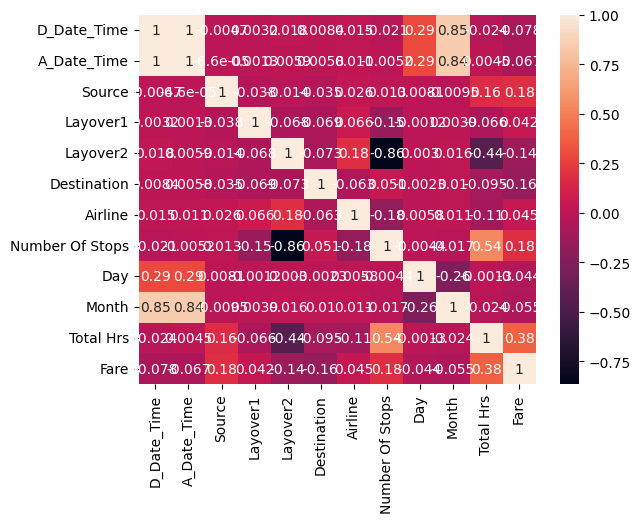

In [140]:
sns.heatmap(df.corr(), annot = True)

In [141]:
df.describe()

,D_Date_Time,A_Date_Time,Source,Layover1,Layover2,Destination,Airline,Number Of Stops,Day,Month,Total Hrs,Fare
count,30024,30024,30024.000000,30024.000000,30024.000000,30024.000000,30024.000000,30024.000000,30024.000000,30024.000000,30024.000000,30024.000000
mean,2020-01-30 12:55:20.095922944,2020-01-31 08:07:13.213429248,69.369538,79.709033,70.817379,38.264722,44.985212,1.332367,15.178091,1.478084,19.198100,34223.542699
min,2020-01-02 00:05:00,2020-01-02 01:55:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.250000,1299.000000
25%,2020-01-18 11:10:00,2020-01-19 08:05:00,33.000000,47.000000,43.000000,17.000000,8.000000,1.000000,8.000000,1.000000,10.420000,9573.750000
50%,2020-01-30 06:10:00,2020-01-30 17:55:00,63.000000,62.000000,93.000000,33.000000,37.000000,1.000000,16.000000,1.000000,18.330000,16289.000000
75%,2020-02-10 13:10:00,2020-02-11 08:46:15,108.000000,124.000000,93.000000,53.000000,72.000000,2.000000,23.000000,2.000000,26.420000,41573.250000
max,2020-02-29 23:55:00,2020-03-03 08:50:00,160.000000,194.000000,93.000000,84.000000,114.000000,3.000000,30.000000,2.000000,82.080000,930341.000000
std,NaN,NaN,42.116370,50.931059,30.931911,24.076691,36.310132,0.554113,8.650791,0.499528,10.647467,48169.945151


#Encoding of Independent & Dependent Data

In [143]:
X = df.iloc[:, 2:-1]
y = df.iloc[:, -1]

In [145]:
X

,Source,Layover1,Layover2,Destination,Airline,Number Of Stops,Day,Month,Total Hrs
0,50,126,23,45,76,2,6,2,20.42
1,43,194,93,60,97,0,1,2,1.67
2,108,148,43,71,8,2,23,1,21.33
3,110,124,29,65,8,2,3,2,17.58
4,108,75,93,82,51,1,6,1,9.25
...,...,...,...,...,...,...,...,...,...
30019,43,75,58,82,8,2,27,2,19.42
30020,140,97,23,1,72,2,8,2,19.17
30021,109,124,23,50,8,2,3,2,19.33
30022,62,4,93,29,51,1,6,2,8.83


In [147]:
y

,Fare
0,26224.0
1,2889.0
2,13518.0
3,12528.0
4,8240.0
...,...
30019,11651.0
30020,56035.0
30021,18652.0
30022,6201.0


#Splitting the dataset into the Training set and Test set

In [169]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model Training

In [170]:
class FlightPriceRegressor(nn.Module):
    def __init__(self, input_size):
        super(FlightPriceRegressor, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

model = FlightPriceRegressor(input_size=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [171]:
epochs = 100
train_losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')

Epoch [20/100], Loss: 1783928861.1364
Epoch [40/100], Loss: 1741649229.7045
Epoch [60/100], Loss: 1720197992.6364
Epoch [80/100], Loss: 1709667103.5114
Epoch [100/100], Loss: 1696286902.1818


In [172]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.numpy().flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_test_np = y_test_tensor.numpy().flatten()
y_pred_np = y_pred

acc_r2 = r2_score(y_test_np, y_pred_np) * 100
MAE = mean_absolute_error(y_test_np, y_pred_np)
MSE = mean_squared_error(y_test_np, y_pred_np)
RMSE = np.sqrt(MSE)

print("PyTorch Neural Network")
print(f"R² Score: {acc_r2:.2f}%")
print(f"MAE: {MAE:.2f}")
print(f"MSE: {MSE:.2f}")
print(f"RMSE: {RMSE:.2f}")

PyTorch Neural Network
R² Score: 30.00%
MAE: 18884.08
MSE: 1650838144.00
RMSE: 40630.51


#Performance Analysis

In [173]:
performance_df = pd.DataFrame({
    'Algorithm': ['PyTorch Neural Network', 'Random Forest Regressor', 'Linear Regression', 'Decision Tree Regressor'],
    'Training Accuracy': [acc_r2, acc_rfrTrain, acc_lrTrain, acc_dtrTrain],
    'Testing Accuracy': [acc_r2, acc_rfrTest, acc_lrTest, acc_dtrTest],
    'RMSE': [RMSE, RMSE_RFR, RMSE_LR, RMSE_DTR]
}).set_index('Algorithm')

performance_df.sort_values('Testing Accuracy', ascending=False)

,Training Accuracy,Testing Accuracy,RMSE
Algorithm,,,
Random Forest Regressor,95.269417,66.848498,27961.255472
Decision Tree Regressor,52.352591,66.848498,35486.955809
PyTorch Neural Network,30.000585,30.000585,40630.507553
Linear Regression,18.490295,20.107079,43406.944099


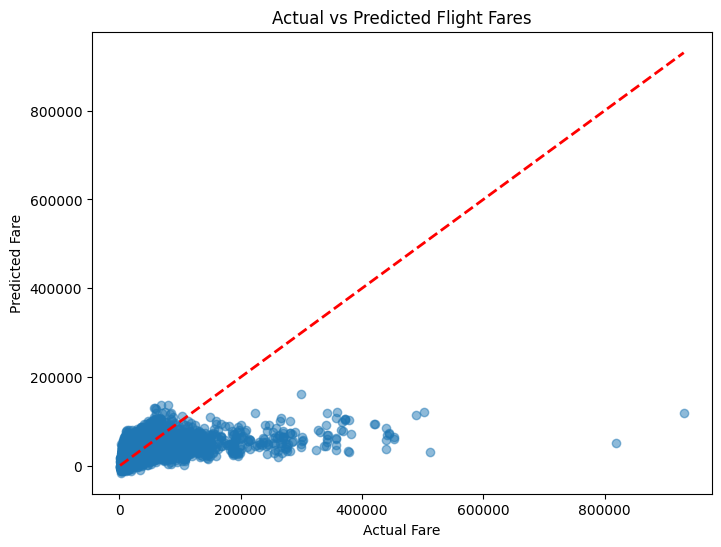

In [178]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_predLR, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Actual vs Predicted Flight Fares')
plt.show()

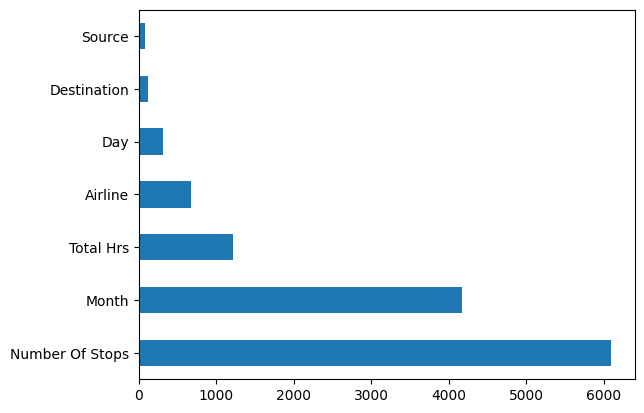

In [174]:

model.eval()
X_test_tensor.requires_grad = True
output = model(X_test_tensor)
grads = torch.autograd.grad(outputs=output, inputs=X_test_tensor, grad_outputs=torch.ones_like(output))
importance = grads[0].abs().mean(dim=0).detach().numpy()

feat_importances = pd.Series(importance, index=X_train.columns)
feat_importances.nlargest(7).plot(kind='barh')
plt.show()